<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet4/Tugas%20Praktikum%20DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Tugas DBSCAN

1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Buat dataset make_moons (1000 sampel, noise=0.05)
X_moons, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

# 2. Normalisasi/Standardisasi data
X_scaled = StandardScaler().fit_transform(X_moons)

2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.

In [7]:
# Terapkan DBSCAN
db = DBSCAN(eps=0.2, min_samples=5).fit(X_scaled)
labels = db.labels_

# Hitung jumlah klaster dan noise
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Hitung jumlah titik noise (yang berlabel -1)
n_noise_ = list(labels).count(-1)

print(f"Jumlah klaster terdeteksi : {n_clusters_}")
print(f"Jumlah titik noise        : {n_noise_}")

Jumlah klaster terdeteksi : 2
Jumlah titik noise        : 0


3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.

In [8]:
print("--- METRIK EVALUASI DBSCAN (eps=0.2, min_samples=5) ---")
print(f"Homogeneity: {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index (ARI): {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(f"Adjusted Mutual Information (AMI): {metrics.adjusted_mutual_info_score(y_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_scaled, labels):.3f}")

--- METRIK EVALUASI DBSCAN (eps=0.2, min_samples=5) ---
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index (ARI): 1.000
Adjusted Mutual Information (AMI): 1.000
Silhouette Coefficient: 0.391


4.
Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).

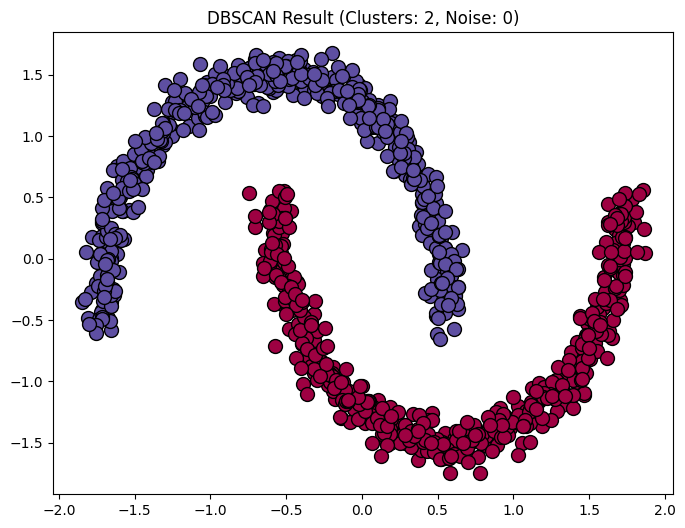

In [9]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Menentukan variasi warna dengan np.linspace agar warna terbagi rata 0.0 - 1.0
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Hitam untuk noise
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Plot core samples (titik besar)
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=10)

    # Plot non-core samples (titik kecil)
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=4)

plt.title(f"DBSCAN Result (Clusters: {n_clusters_}, Noise: {n_noise_})")
plt.show()

5. Lakukan eksperimen:

- eps = 0.05, 0.1, 0.3, 0.5

- min_samples = 3, 10, 20

- Catat perubahan klaster, noise, dan kualitas evaluasi.

In [10]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print("=== HASIL EKSPERIMEN PARAMETER DBSCAN ===")
print(f"{'eps':<6} | {'min_samp':<8} | {'Clusters':<8} | {'Noise':<6} | {'ARI':<6} | {'Silhouette':<10}")
print("-" * 60)

for eps in eps_values:
    for min_samp in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samp).fit(X_scaled)
        lbls = model.labels_

        n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n = list(lbls).count(-1)

        # Hitung metrik jika cluster terdeteksi > 1
        if n_c > 1:
            ari = metrics.adjusted_rand_score(y_true, lbls)
            sil = metrics.silhouette_score(X_scaled, lbls)
        else:
            ari = 0.0
            sil = -1.0

        print(f"{eps:<6} | {min_samp:<8} | {n_c:<8} | {n_n:<6} | {ari:<6.3f} | {sil:<10.3f}")

=== HASIL EKSPERIMEN PARAMETER DBSCAN ===
eps    | min_samp | Clusters | Noise  | ARI    | Silhouette
------------------------------------------------------------
0.05   | 3        | 69       | 186    | 0.030  | 0.113     
0.05   | 10       | 3        | 970    | 0.002  | -0.294    
0.05   | 20       | 0        | 1000   | 0.000  | -1.000    
0.1    | 3        | 2        | 14     | 0.972  | 0.252     
0.1    | 10       | 7        | 57     | 0.523  | 0.162     
0.1    | 20       | 6        | 850    | 0.017  | -0.360    
0.3    | 3        | 2        | 0      | 1.000  | 0.391     
0.3    | 10       | 2        | 0      | 1.000  | 0.391     
0.3    | 20       | 2        | 0      | 1.000  | 0.391     
0.5    | 3        | 2        | 0      | 1.000  | 0.391     
0.5    | 10       | 2        | 0      | 1.000  | 0.391     
0.5    | 20       | 2        | 0      | 1.000  | 0.391     
